<a href="https://colab.research.google.com/github/kaplangorde/pangeos_oxford_summerschool/blob/main/RS_Forest_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to our Interdisciplinary Summer School on Forests Oxford, U.K.

IMPORTANT: File --> Save a copy in Drive

In [ ]:
!pip install earthengine-api

#Introduction

##Installing Google Earth Engine (GEE) Python API and geemap (just once)

In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.1 MB/s eta 0:00:00


Authentication and access to your GEE account (accept everything or it won't work)

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import datetime

ee.Authenticate()

We always need to connect to a specific Google Cloud project: yours or, in this case, mine - which it was created for this tutorial and added you to (you are all entitled to create a certain number of them for free).

In [ ]:
ee.Initialize(project='pangeos-forest-training')

#OK! We are in!

But first!

Let`s remember the basics! Resolution in Remote Sensing!

1. Spatial resolution - the actual area that each pixel of an image represents on the ground; expressed in metric units or degrees (0.1° ≈ 11.1 km).

2. Temporal resolution - how often do we have a new image over the same area; expressed in days for dynamic datasets, while static datasets (e.g., land cover, elevation) are updated infrequently.

3. Spectral resolution - number and width of spectral bands captured by a sensor (wavelength range); narrower bands = higher spectral resolution; in most cases not something to worry about, but something to be aware of, especially when detecting subtle differences in material properties (e.g., vegetation health, water quality, or mineral composition).


Another thing we need to be aware of is the different types of data in Google Earth Engine (GEE):

Feature - geometric data (points, polygons) defined by coordinates and name (ee.Feature) --> we can define them, import them directly from GEE catalog or import local vector files containing our features of interest (shapefile (better) or csv format).
Image - raster data built from pixels and can have multiple bands (ee.Image) - important to always specify which band you want --> we will usually access these datasets directly from GEE catalog, but they can also be imported (usually GeoTiff format).
Collection - groups of features (ee.FeatureCollection) or images (ee.ImageCollection) --> we will mostly work with image collections from the GEE catalog, always keeping in mind their spatial and temporal resolution, which will almost always differ from one data provider to another!

Time to play!

Everything below is organized into different sections for different tasks, so you can keep it tidy and close what you don't need at the moment. Keep it clean, it will be easier for you ✨

#A little bit about the tree data!

We have taken the data for the Fagus Orientalis tree coordinates from the Eufgis portal.

http://portal.eufgis.org/

This website provides you with geo-referenced information on the conservation of forest genetic resources in Europe and access to detailed data on dynamic gene conservation units of forest trees in different countries. The data is provided and frequently updated by national focal points based on pan-European minimum requirements and data standards for the units.

EUFGIS serves as a documentation platform linking national inventories on forest genetic resources in Europe. This supports the countries in their efforts to conserve forest genetic resources as part of sustainable forest management, as agreed in the context of Forest Europe, the pan-European forest policy process.

As of today, the EUFGIS database contains information on 3231 units and 113 tree species in 35 countries. The units harbour a total of 4017 tree populations.

http://portal.eufgis.org/search/simple/list/?tx_wfqbe_pi1[country_name]=Turkey&tx_wfqbe_pi1[target_species]=Fagus%20orientalis&tx_wfqbe_pi1[unit_type]=

You can find other tree species on different parts in Europe!

In [ ]:
data = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([41.366667, 41.025556]), {'name': 'ID_1', 'class': 1}),
    ee.Feature(ee.Geometry.Point([29.4075, 39.930278]), {'name': 'ID_2', 'class': 1}),
    ee.Feature(ee.Geometry.Point([35.237778, 40.077222]), {'name': 'ID_3', 'class': 1}),
    ee.Feature(ee.Geometry.Point([36.376667, 37.746944]), {'name': 'ID_4', 'class': 1}),
    ee.Feature(ee.Geometry.Point([37.102222, 40.785278]), {'name': 'ID_5', 'class': 1}),
    ee.Feature(ee.Geometry.Point([27.313889, 42.014167]), {'name': 'ID_6', 'class': 1}),
    ee.Feature(ee.Geometry.Point([27.441944, 41.964167]), {'name': 'ID_7', 'class': 1}),
    ee.Feature(ee.Geometry.Point([27.596111, 41.825278]), {'name': 'ID_8', 'class': 1}),
    ee.Feature(ee.Geometry.Point([29.603889, 39.870833]), {'name': 'ID_9', 'class': 1}),
    ee.Feature(ee.Geometry.Point([39.035556, 40.691944]), {'name': 'ID_10', 'class': 1}),
    ee.Feature(ee.Geometry.Point([28.786111, 39.258333]), {'name': 'ID_11', 'class': 1}),
    ee.Feature(ee.Geometry.Point([33.169444, 41.316667]), {'name': 'ID_12', 'class': 1}),
    ee.Feature(ee.Geometry.Point([33.843889, 41.933333]), {'name': 'ID_13', 'class': 1}),
    ee.Feature(ee.Geometry.Point([33.787222, 41.858889]), {'name': 'ID_14', 'class': 1}),
    ee.Feature(ee.Geometry.Point([33.611667, 41.770556]), {'name': 'ID_15', 'class': 1}),
    ee.Feature(ee.Geometry.Point([28.45, 39.864722]), {'name': 'ID_16', 'class': 1}),
    ee.Feature(ee.Geometry.Point([28.378056, 39.883333]), {'name': 'ID_17', 'class': 1}),
    ee.Feature(ee.Geometry.Point([29.637778, 39.8875]), {'name': 'ID_18', 'class': 1}),
    ee.Feature(ee.Geometry.Point([32.926944, 41.711111]), {'name': 'ID_19', 'class': 1}),
    ee.Feature(ee.Geometry.Point([28.359167, 39.848889]), {'name': 'ID_20', 'class': 1}),
    ee.Feature(ee.Geometry.Point([27.188333, 39.877778]), {'name': 'ID_21', 'class': 1}),
    ee.Feature(ee.Geometry.Point([36.137778, 37.7]), {'name': 'ID_22', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.929722, 42.0375]), {'name': 'ID_23', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.860556, 41.811944]), {'name': 'ID_24', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.860833, 41.826111]), {'name': 'ID_25', 'class': 1}),
    ee.Feature(ee.Geometry.Point([33.975, 41.847778]), {'name': 'ID_26', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.586111, 41.804444]), {'name': 'ID_27', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.785, 41.245833]), {'name': 'ID_28', 'class': 1}),
    ee.Feature(ee.Geometry.Point([27.661667, 41.765833]), {'name': 'ID_29', 'class': 1}),
    ee.Feature(ee.Geometry.Point([28.633889, 39.401111]), {'name': 'ID_30', 'class': 1}),
    ee.Feature(ee.Geometry.Point([41.9, 41.3]), {'name': 'ID_42', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.9475, 41.921944]), {'name': 'ID_43', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.589444, 41.701111]), {'name': 'ID_44', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.392222, 41.965]), {'name': 'ID_45', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.950278, 42.011944]), {'name': 'ID_46', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.735556, 41.836111]), {'name': 'ID_47', 'class': 1}),
    ee.Feature(ee.Geometry.Point([34.984722, 41.166667]), {'name': 'ID_48', 'class': 1}),
    ee.Feature(ee.Geometry.Point([35.207222, 41.069722]), {'name': 'ID_49', 'class': 1}),
    ee.Feature(ee.Geometry.Point([32.434722, 41.248056]), {'name': 'ID_50', 'class': 1}),
    ee.Feature(ee.Geometry.Point([39.426944, 40.669444]), {'name': 'ID_51', 'class': 1}),
    ee.Feature(ee.Geometry.Point([40.211944, 40.682778]), {'name': 'ID_52', 'class': 1}),
    ee.Feature(ee.Geometry.Point([38.320833, 40.680278]), {'name': 'ID_53', 'class': 1}),
    ee.Feature(ee.Geometry.Point([37.001944, 40.810556]), {'name': 'ID_54', 'class': 1}),
    ee.Feature(ee.Geometry.Point([31.286667, 40.636111]), {'name': 'ID_55', 'class': 1}),
])


In [ ]:
# Let's visualize it on a map to check if our coordinates are correct
import geemap # library we need --> enough to do it once

Map = geemap.Map()
Map.centerObject(data, zoom=7) # center map automatically by layer
Map.addLayer(data, {}, "Fagus")
Map

Map(center=[40.983860724233615, 33.480951342083024], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# Load Turkey boundary from LSIB dataset
turkey = (ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
          .filter(ee.Filter.eq('country_na', 'Turkey'))
          .geometry())


#Phenology

We want to take any point in the dataset and visualize the phenology over the years through NDVI. Ideally, we would work with all the points, but the data is too large! We get over 5000 elements, and thus gee crashes :(

As an example, we work with a single point. Feel free to change the ID of the point to get the phenology of different point/location.

Also, we want to see see where is our point, so we map it!

Try it!

In [ ]:
# Use any point from your data
point = ee.Feature(data.toList(data.size()).get(3)).geometry()

# Load Sentinel-2 and compute NDVI
def add_ndvi(img):
    return img.addBands(img.normalizedDifference(['B8', 'B4']).rename('NDVI'))

ndvi_collection = (ee.ImageCollection("COPERNICUS/S2_SR")
                   .filterDate('2016-01-01', '2024-12-31')
                   .filterBounds(point)
                   .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
                   .map(add_ndvi)
                   .select('NDVI'))

# Extract NDVI values over time
def extract(img):
    return ee.Feature(None, {
        'date': img.date().format('YYYY-MM-dd'),
        'NDVI': img.reduceRegion(ee.Reducer.mean(), point, 20).get('NDVI')
    })

ts = ndvi_collection.map(extract).getInfo()

# Convert to DataFrame
dates = [datetime.datetime.strptime(f['properties']['date'], '%Y-%m-%d') for f in ts['features']]
values = [f['properties']['NDVI'] for f in ts['features']]
df = pd.DataFrame({'date': dates, 'NDVI': values}).dropna()

# Map the point
import geemap

Map = geemap.Map(center=point.coordinates().getInfo()[::-1], zoom=10)
Map.addLayer(ee.Feature(point), {'color': 'red'}, 'Selected Fagus Point')
Map


Map(center=[37.746944, 36.376667], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…

##NDVI normalization
Now we know remote sensing can do miracles, but we also know there is a lot of noise in the data. Lets not forget we are looking at trees from space!

To minimize the noise, and be able to make a yearly comparison of the data, it would be a good idea to normalize the NDVI values. Here we use the min/max function.


In [ ]:
# Ensure date column is datetime
df['year'] = df['date'].dt.year

# Normalize NDVI per year
df_norm = pd.DataFrame()

for year in df['year'].unique():
    df_year = df[df['year'] == year].copy()
    min_val = df_year['NDVI'].min()
    max_val = df_year['NDVI'].max()
    df_year['NDVI_norm'] = (df_year['NDVI'] - min_val) / (max_val - min_val)
    df_norm = pd.concat([df_norm, df_year])


##Phenology plot

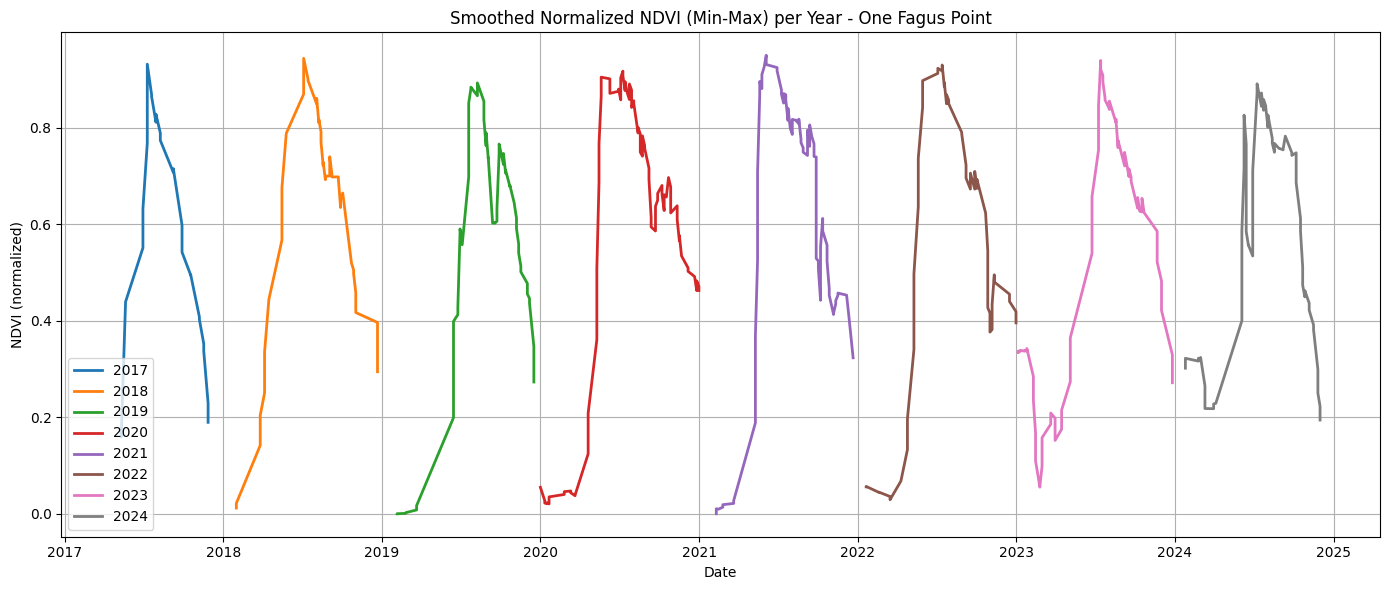

In [ ]:
plt.figure(figsize=(14, 6))

for year in sorted(df_norm['year'].unique()):
    subset = df_norm[df_norm['year'] == year].sort_values('date').reset_index(drop=True)
    subset['NDVI_norm_smooth'] = subset['NDVI_norm'].rolling(window=5, min_periods=1).mean()  # Smoother line
    plt.plot(subset['date'], subset['NDVI_norm_smooth'], label=str(year), linewidth=2)

plt.title('Smoothed Normalized NDVI (Min-Max) per Year - One Fagus Point')
plt.xlabel('Date')
plt.ylabel('NDVI (normalized)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#Single-class classification

In [ ]:
# Load Sentinel-2 (median composite)
s2 = (ee.ImageCollection("COPERNICUS/S2_SR")
      .filterDate('2023-06-01', '2023-08-31')
      .filterBounds(data)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .median())

# Add NDVI
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')
s2 = s2.addBands(ndvi)

# Apply NDVI mask
ndvi_mask = ndvi.gt(0.6)
s2_masked = s2.updateMask(ndvi_mask)

print("✅ Step 1 complete: Sentinel-2 NDVI masked image loaded.")

# Quick map to see NDVI
import geemap
Map1 = geemap.Map()
Map1.centerObject(data, zoom=7)
Map1.addLayer(ndvi, {'min': 0, 'max': 1, 'palette': ['white', 'green']}, 'NDVI')
Map1.addLayer(ndvi_mask.selfMask(), {'palette': ['blue']}, 'NDVI > 0.6 Mask')
Map1


✅ Step 1 complete: Sentinel-2 NDVI masked image loaded.


Map(center=[40.983860724233615, 33.480951342083024], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
bands = ['B2', 'B3', 'B4', 'B5','B6','B7','B8','B8A','B11','B12']
image = s2_masked.select(bands)

# Sample spectral values at Fagus points
samples = image.sampleRegions(
    collection=data,
    properties=['class'],
    scale=10
)

# Compute band-wise mean
mean_vector = ee.List([
    samples.aggregate_mean('B2'),
    samples.aggregate_mean('B3'),
    samples.aggregate_mean('B4'),
    samples.aggregate_mean('B5'),
    samples.aggregate_mean('B6'),
    samples.aggregate_mean('B7'),
    samples.aggregate_mean('B8'),
    samples.aggregate_mean('B8A'),
    samples.aggregate_mean('B11'),
    samples.aggregate_mean('B12')
])

print("✅ Step 2 complete: Fagus mean vector calculated.")
mean_vector.getInfo()  # View mean values (optional)


✅ Step 2 complete: Fagus mean vector calculated.


[1253.1538461538462,
 1457.6538461538462,
 1242.576923076923,
 1849.923076923077,
 4424.788461538462,
 5428.711538461538,
 5550.903846153846,
 5758.403846153846,
 3193.6923076923076,
 1961.6153846153845]

In [ ]:
# Convert mean vector to constant image
mean_image = ee.Image.constant(mean_vector).rename(bands)

# Compute distance to mean vector
diff = image.subtract(mean_image)
distance = diff.pow(2).reduce('sum').sqrt().rename('distance')

print("✅ Step 3 complete: Euclidean distance image created.")

✅ Step 3 complete: Euclidean distance image created.


In [ ]:
# Visual check
Map2 = geemap.Map()
Map2.centerObject(data, zoom=7)
Map2.addLayer(distance, {'min': 0, 'max': 400, 'palette': ['white', 'black']}, 'Distance to Fagus')
Map2

Map(center=[40.983860724233615, 33.480951342083024], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# Threshold distance: adjust 150–300 as needed
fagus_likely = distance.lt(1000).selfMask()

print("✅ Step 4 complete: Fagus-like pixels classified.")

# Quick binary mask map
Map3 = geemap.Map()
Map3.centerObject(data, zoom=7)
Map3.addLayer(fagus_likely, {'palette': ['green']}, 'Fagus-like Pixels')
Map3.addLayer(data, {'color': 'red'}, 'Fagus Points')
Map3


✅ Step 4 complete: Fagus-like pixels classified.


Map(center=[40.983860724233615, 33.480951342083024], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# Step 6: Count how many Fagus points fall inside the classified area

# Convert the mask to a binary image (1 where true, 0 elsewhere)
fagus_mask = fagus_likely.selfMask()

# Check which points intersect the classified pixels
points_in_mask = fagus_mask.reduceRegions(
    collection=data,
    reducer=ee.Reducer.first(),
    scale=10
)

# Filter points that got a classification (i.e., are inside the mask)
points_inside = points_in_mask.filter(ee.Filter.neq('first', None))

# Count how many points matched
total_points = data.size()
matched_points = points_inside.size()

# Print the result
print("✅ Final Accuracy Check")
print('Total Fagus points:', total_points.getInfo())
print('Points inside classified Fagus-like area:', matched_points.getInfo())


✅ Final Accuracy Check
Total Fagus points: 44
Points inside classified Fagus-like area: 16
